# MagicAdjuster Tutorial

This notebook demonstrates how to use the `MagicAdjuster` class for statistical distribution fitting and analysis.

## Overview

`MagicAdjuster` is designed to:
- Fit statistical distributions to your data
- Perform goodness-of-fit tests (KS, Chi-square, RMSE)
- Provide seamless access to all SciPy distribution methods
- Run Monte Carlo stability analysis

## Setup and Data Generation

Let's start by importing the necessary libraries and generating some sample wind speed data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import magica as ma
from magica.core import DataProcessor, MagicAdjuster

# Set random seed for reproducibility
np.random.seed(42)

# Generate sample wind speed data (Weibull-like distribution)
n_samples = 1000
wind_speeds = np.random.weibull(2, n_samples) * 8 + 2  # Scale and shift

print(f"Generated {n_samples} wind speed measurements")
print(f"Min: {wind_speeds.min():.2f} m/s")
print(f"Max: {wind_speeds.max():.2f} m/s")
print(f"Mean: {wind_speeds.mean():.2f} m/s")
print(f"Std: {wind_speeds.std():.2f} m/s")

Generated 1000 wind speed measurements
Min: 2.55 m/s
Max: 24.87 m/s
Mean: 8.97 m/s
Std: 3.69 m/s


## Basic Usage: Loading Data and Fitting a Distribution

In [2]:
# Load data using MagicA's DataProcessor
processor = ma.read_data(wind_speeds)
print(f"Loaded data: {processor}")

# Get basic statistics
stats = processor.get_basic_stats()
for key, value in stats.items():
    print(f"{key}: {value:.4f}")

Loaded data: DataProcessor(length=1000, dtype=float64)
count: 1000.0000
mean: 8.9709
std: 3.6961
var: 13.6609
min: 2.5451
max: 24.8700
median: 8.6298
q25: 6.1504
q75: 11.3426


In [3]:
# Fit a Weibull distribution (common for wind data)
processor.fit_distribution('weibull_min')
print(f"Updated processor: {processor}")

# Get fitted parameters
params = processor.get_fitted_params()
print(f"\nFitted Weibull parameters:")
print(f"Shape (c): {params[0]:.4f}")
print(f"Location (loc): {params[1]:.4f}")
print(f"Scale: {params[2]:.4f}")

# Get distribution info
info = processor.get_distribution_info()
print(f"\nDistribution info:")
for key, value in info.items():
    print(f"{key}: {value}")

Updated processor: DataProcessor(length=1000, dtype=float64, distribution='weibull_min')

Fitted Weibull parameters:
Shape (c): 1.8487
Location (loc): 2.3531
Scale: 7.4447

Distribution info:
name: weibull_min
parameters: (np.float64(1.8486974637812565), np.float64(2.3531115620951226), np.float64(7.4447412667075525))
num_params: 3
data_size: 1000


## Accessing SciPy Methods Directly

Once a distribution is fitted, you can access all SciPy distribution methods directly through the processor.

In [4]:
# Smart defaults: evaluate at original data points
pdf_values = processor.pdf()  # PDF at all original data points
cdf_values = processor.cdf()  # CDF at all original data points

print(f"PDF values (first 10): {pdf_values[:10]}")
print(f"CDF values (first 10): {cdf_values[:10]}")

# Custom inputs also work
prob_10ms = processor.cdf(10.0)  # P(wind speed ≤ 10 m/s)
percentile_95 = processor.ppf(0.95)  # 95th percentile wind speed

print(f"\nP(wind speed ≤ 10 m/s): {prob_10ms:.4f}")
print(f"95th percentile wind speed: {percentile_95:.2f} m/s")

# Generate random samples from fitted distribution
random_samples = processor.rvs(size=5)
print(f"5 random wind speed samples: {random_samples}")

PDF values (first 10): [0.10954842 0.0201954  0.07291156 0.09321379 0.09435054 0.09434594
 0.06364648 0.0442638  0.09290786 0.07711357]
CDF values (first 10): [0.39457944 0.95100694 0.74589473 0.6179072  0.16446916 0.16444297
 0.05686516 0.87194422 0.62029511 0.7231631 ]

P(wind speed ≤ 10 m/s): 0.6503
95th percentile wind speed: 15.83 m/s
5 random wind speed samples: [ 5.50995661  8.8646398  13.3681271  10.99571328 12.09096196]


## Goodness-of-Fit Testing

Evaluate how well the distribution fits your data using various statistical tests.

In [5]:
# Kolmogorov-Smirnov test
ks_result = processor.goodness_of_fit('ks')
print("Kolmogorov-Smirnov Test:")
print(f"  Statistic: {ks_result['ks_statistic']:.6f}")
print(f"  P-value: {ks_result['p_value']:.6f}")
print(f"  Result: {'Good fit' if ks_result['p_value'] > 0.05 else 'Poor fit'} (α = 0.05)")

# Chi-square test
chi2_result = processor.goodness_of_fit('chi2')
print("\nChi-square Test:")
print(f"  Statistic: {chi2_result['chi2_statistic']:.6f}")
print(f"  P-value: {chi2_result['p_value']:.6f}")
print(f"  Bins used: {chi2_result['n_bins']}")
print(f"  Result: {'Good fit' if chi2_result['p_value'] > 0.05 else 'Poor fit'} (α = 0.05)")

# RMSE
rmse = processor.goodness_of_fit('rmse')
print(f"\nRoot Mean Square Error: {rmse:.6f}")

Kolmogorov-Smirnov Test:
  Statistic: 0.022647
  P-value: 0.675447
  Result: Good fit (α = 0.05)

Chi-square Test:
  Statistic: 12.338939
  P-value: 0.500066
  Bins used: 14
  Result: Good fit (α = 0.05)

Root Mean Square Error: 0.005472

Root Mean Square Error: 0.005472


/home/daniloceano/Documents/Programs_and_scripts/MagicA/magica/core/magic_adjuster.py:445: UserWarning: Normalizing expected frequencies. Original sum: 998.407739, Target sum: 1000
  warnings.warn(f"Normalizing expected frequencies. Original sum: {expected_freq.sum():.6f}, "


### Understanding Chi-square Test and Number of Bins

The chi-square goodness-of-fit test compares observed frequencies in histogram bins with expected frequencies from the fitted distribution. The number of bins significantly affects the test results.

In [6]:
# Demonstrate different binning methods for chi-square test
binning_methods = ['doane', 'sturges', 'freedman-diaconis', 'rice', 'scott', 30]

print("Chi-square Test Results with Different Binning Methods:")
print("-" * 70)
print(f"{'Method':<20} {'Bins':<6} {'Chi2 Stat':<12} {'P-value':<12} {'Result'}")
print("-" * 70)

for method in binning_methods:
    chi2_result = processor.goodness_of_fit('chi2', bins=method)
    result_text = 'Good fit' if chi2_result['p_value'] > 0.05 else 'Poor fit'
    method_name = str(method) if isinstance(method, int) else method
    
    print(f"{method_name:<20} {chi2_result['n_bins']:<6} {chi2_result['chi2_statistic']:<12.4f} "
          f"{chi2_result['p_value']:<12.6f} {result_text}")

print("\nBinning Method Guidelines:")
print("- Doane: Best for skewed distributions (default)")
print("- Sturges: Good for normal distributions, conservative")
print("- Freedman-Diaconis: Robust for various distributions")
print("- Rice: Simple rule, scales with cube root of sample size")
print("- Scott: Minimizes integrated mean square error")
print("- Fixed number: Use when you need specific bin count")

Chi-square Test Results with Different Binning Methods:
----------------------------------------------------------------------
Method               Bins   Chi2 Stat    P-value      Result
----------------------------------------------------------------------
doane                14     12.3389      0.500066     Good fit
sturges              10     8.4626       0.488279     Good fit
freedman-diaconis    21     17.3856      0.627811     Good fit
rice                 19     10.8226      0.901733     Good fit
scott                17     19.6356      0.237085     Good fit
30                   30     29.3177      0.448617     Good fit

Binning Method Guidelines:
- Doane: Best for skewed distributions (default)
- Sturges: Good for normal distributions, conservative
- Freedman-Diaconis: Robust for various distributions
- Rice: Simple rule, scales with cube root of sample size
- Scott: Minimizes integrated mean square error
- Fixed number: Use when you need specific bin count
30                

## Visualization: Comparing Data and Fitted Distribution

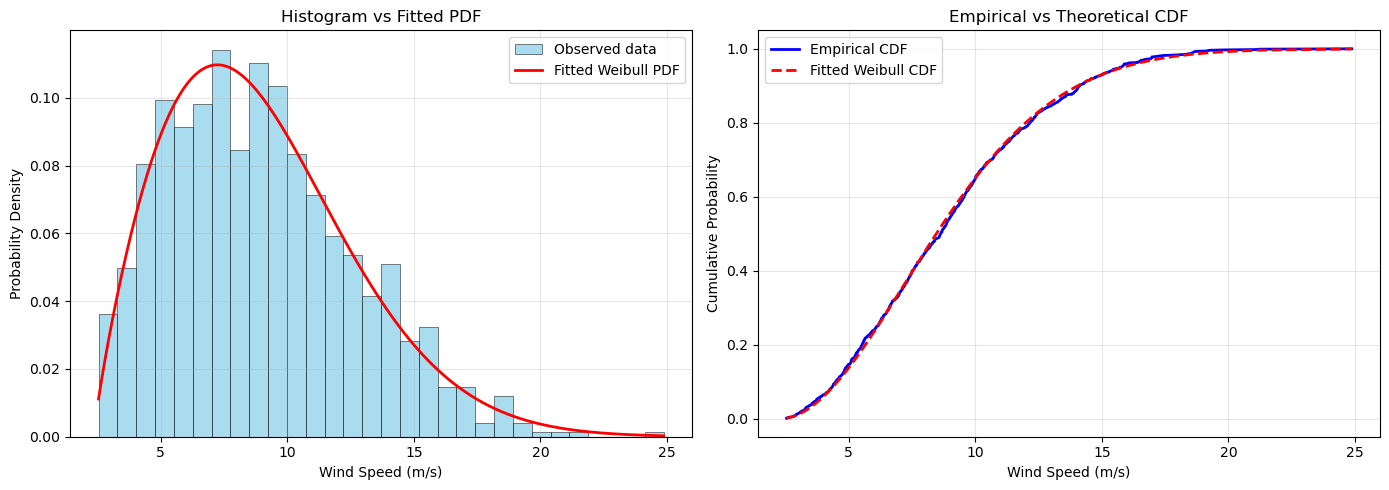

In [7]:
# Create comparison plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Histogram with fitted PDF
ax1.hist(wind_speeds, bins=30, density=True, alpha=0.7, color='skyblue', 
         label='Observed data', edgecolor='black', linewidth=0.5)

# Generate smooth curve for fitted distribution
x_smooth = np.linspace(wind_speeds.min(), wind_speeds.max(), 1000)
pdf_smooth = processor.pdf(x_smooth)
ax1.plot(x_smooth, pdf_smooth, 'r-', linewidth=2, label='Fitted Weibull PDF')

ax1.set_xlabel('Wind Speed (m/s)')
ax1.set_ylabel('Probability Density')
ax1.set_title('Histogram vs Fitted PDF')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Empirical vs Theoretical CDF
sorted_data = np.sort(wind_speeds)
empirical_cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
theoretical_cdf = processor.cdf(sorted_data)

ax2.plot(sorted_data, empirical_cdf, 'b-', linewidth=2, label='Empirical CDF')
ax2.plot(sorted_data, theoretical_cdf, 'r--', linewidth=2, label='Fitted Weibull CDF')

ax2.set_xlabel('Wind Speed (m/s)')
ax2.set_ylabel('Cumulative Probability')
ax2.set_title('Empirical vs Theoretical CDF')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Using Different Distributions

Let's try fitting other distributions to see which one works best.

In [8]:
# Test different distributions
distributions_to_test = ['weibull_min', 'lognorm', 'gamma', 'norm', 'expon']
results = []

for dist_name in distributions_to_test:
    # Create a fresh processor for each distribution
    temp_processor = ma.read_data(wind_speeds)
    temp_processor.fit_distribution(dist_name)
    
    # Calculate goodness-of-fit metrics
    ks_test = temp_processor.goodness_of_fit('ks')
    rmse = temp_processor.goodness_of_fit('rmse')
    
    results.append({
        'distribution': dist_name,
        'ks_pvalue': ks_test['p_value'],
        'rmse': rmse,
        'parameters': temp_processor.get_fitted_params()
    })

# Display results
print("Distribution Comparison:")
print("-" * 60)
print(f"{'Distribution':<15} {'KS p-value':<12} {'RMSE':<10} {'Fit Quality'}")
print("-" * 60)

for result in results:
    quality = "Good" if result['ks_pvalue'] > 0.05 else "Poor"
    print(f"{result['distribution']:<15} {result['ks_pvalue']:<12.6f} {result['rmse']:<10.6f} {quality}")

# Find best distribution (highest KS p-value)
best_result = max(results, key=lambda x: x['ks_pvalue'])
print(f"\nBest distribution: {best_result['distribution']} (KS p-value: {best_result['ks_pvalue']:.6f})")

Distribution Comparison:
------------------------------------------------------------
Distribution    KS p-value   RMSE       Fit Quality
------------------------------------------------------------
weibull_min     0.675447     0.005472   Good
lognorm         0.220995     0.008687   Good
gamma           0.182802     0.007692   Good
norm            0.004569     0.012739   Poor
expon           0.000000     0.031710   Poor

Best distribution: weibull_min (KS p-value: 0.675447)


## Advanced Usage: Distribution Parameters with Constraints

You can constrain distribution parameters during fitting (e.g., fix location parameter).

In [9]:
# Fit Weibull with fixed location parameter (floc=0)
processor_constrained = ma.read_data(wind_speeds)
processor_constrained.fit_distribution('weibull_min', floc=0)  # Fix location to 0

params_constrained = processor_constrained.get_fitted_params()
print("Weibull with floc=0:")
print(f"Shape (c): {params_constrained[0]:.4f}")
print(f"Location (fixed): {params_constrained[1]:.4f}")
print(f"Scale: {params_constrained[2]:.4f}")

# Compare with unconstrained fit
params_unconstrained = processor.get_fitted_params()
print("\nUnconstrained Weibull:")
print(f"Shape (c): {params_unconstrained[0]:.4f}")
print(f"Location: {params_unconstrained[1]:.4f}")
print(f"Scale: {params_unconstrained[2]:.4f}")

# Compare goodness of fit
ks_constrained = processor_constrained.goodness_of_fit('ks')
ks_unconstrained = processor.goodness_of_fit('ks')

print(f"\nGoodness of fit comparison:")
print(f"Constrained KS p-value: {ks_constrained['p_value']:.6f}")
print(f"Unconstrained KS p-value: {ks_unconstrained['p_value']:.6f}")

Weibull with floc=0:
Shape (c): 2.6060
Location (fixed): 0.0000
Scale: 10.1209

Unconstrained Weibull:
Shape (c): 1.8487
Location: 2.3531
Scale: 7.4447

Goodness of fit comparison:
Constrained KS p-value: 0.221692
Unconstrained KS p-value: 0.675447


## Monte Carlo Stability Analysis

Determine the minimum sample size needed for stable parameter estimation using standard Monte Carlo analysis.

## Large Sample Size Effect and Monte Carlo CPS Method

### The Problem with Large Datasets

When working with very large datasets (>10,000 samples), statistical tests become extremely powerful, making p-values very small even for practically negligible effects. This phenomenon is known as the "large sample size effect."

Let's demonstrate this problem and show how the Monte Carlo CPS (Coefficient/P-value/Sample size) method can help.

> **Note:** In this section, we use real wind speed data from the INMET Rio Grande weather station. INMET is the Brazilian National Institute of Meteorology, and Rio Grande is a coastal city in southern Brazil. When working with synthetic data, the "large sample size effect" (where statistical tests become overly sensitive and p-values become very small) only appears with very large samples. However, with real-world data, this effect can be observed even with much smaller sample sizes. The dataset `INMET_RIO_GRANDE_wind.csv` allows us to demonstrate this phenomenon clearly.

In [10]:
# Load real wind speed data from INMET Rio Grande station
import pandas as pd
import os
from pathlib import Path

# Find the absolute path to the data file (works in Jupyter and scripts)
project_root = Path().resolve().parents[2]
data_path = project_root / 'data' / 'INMET_RIO_GRANDE_wind.csv'

print(f"Loading data from: {data_path}")
rio_grande_df = pd.read_csv(data_path)

# Clean and extract wind speed values (drop missing/invalid entries)
wind_speeds_real = rio_grande_df['wind_speed'].dropna().astype(float).values
large_sample_size = len(wind_speeds_real)

print(f"Loaded real dataset: {large_sample_size} samples")
print(f"Mean: {wind_speeds_real.mean():.2f} m/s")
print(f"Std: {wind_speeds_real.std():.2f} m/s")

# Fit Weibull distribution to large dataset
large_processor = ma.read_data(wind_speeds_real)
large_processor.fit_distribution('weibull_min')

# Compare goodness-of-fit tests between small and large datasets
print("\n" + "="*60)
print("COMPARISON: Small vs Large Dataset")
print("="*60)

# Small dataset results
ks_small = processor.goodness_of_fit('ks')
chi2_small = processor.goodness_of_fit('chi2')

# Large dataset results  
ks_large = large_processor.goodness_of_fit('ks')
chi2_large = large_processor.goodness_of_fit('chi2')

print(f"{'Test':<20} {'Small (n=1000)':<20} {'Large (n='+str(large_sample_size)+')':<20}")
print("-" * 60)
print(f"{'KS p-value':<20} {ks_small['p_value']:<20.6f} {ks_large['p_value']:<20.6f}")
print(f"{'Chi2 p-value':<20} {chi2_small['p_value']:<20.6f} {chi2_large['p_value']:<20.6f}")

print(f"\nPROBLEM: With the large dataset, p-values become extremely small")
print(f"({ks_large['p_value']:.2e}) even though the distribution fit is practically good!")
print(f"This makes it difficult to assess practical significance.")

Loading data from: /home/daniloceano/Documents/Programs_and_scripts/MagicA/data/INMET_RIO_GRANDE_wind.csv
Loaded real dataset: 168230 samples
Mean: 3.45 m/s
Std: 1.91 m/s

COMPARISON: Small vs Large Dataset
Test                 Small (n=1000)       Large (n=168230)    
------------------------------------------------------------
KS p-value           0.675447             0.000000            
Chi2 p-value         0.500066             0.000000            

PROBLEM: With the large dataset, p-values become extremely small
(4.27e-65) even though the distribution fit is practically good!
This makes it difficult to assess practical significance.

COMPARISON: Small vs Large Dataset
Test                 Small (n=1000)       Large (n=168230)    
------------------------------------------------------------
KS p-value           0.675447             0.000000            
Chi2 p-value         0.500066             0.000000            

PROBLEM: With the large dataset, p-values become extremely small
(4

/home/daniloceano/Documents/Programs_and_scripts/MagicA/magica/core/magic_adjuster.py:445: UserWarning: Normalizing expected frequencies. Original sum: 998.407739, Target sum: 1000
  warnings.warn(f"Normalizing expected frequencies. Original sum: {expected_freq.sum():.6f}, "
/home/daniloceano/Documents/Programs_and_scripts/MagicA/magica/core/magic_adjuster.py:445: UserWarning: Normalizing expected frequencies. Original sum: 167543.332352, Target sum: 168230
  warnings.warn(f"Normalizing expected frequencies. Original sum: {expected_freq.sum():.6f}, "


### The Monte Carlo CPS Solution

The Monte Carlo CPS method addresses this by:

1. **Testing multiple subsample sizes** to understand how parameters and p-values evolve
2. **Finding the stability point** where coefficients converge but p-values aren't yet inflated
3. **Providing empirical distributions** that are more interpretable for practical significance

Let's run a comprehensive CPS analysis with detailed options:

Running Monte Carlo CPS Analysis on Large Dataset...
This will take a moment as we test multiple subsample sizes...



Monte Carlo sizes: 100%|██████████| 10/10 [00:06<00:00,  1.45it/s]



✓ Monte Carlo CPS analysis completed!
Results dimensions: {'sizes': 10, 'repeats': 50}
Available variables: ['param_0', 'param_1', 'param_2', 'ks_statistic', 'ks_pvalue', 'chi2_statistic', 'chi2_pvalue', 'rmse']
Figure saved to: cps_analysis.png

Stability Analysis Results:
----------------------------------------
✓ RMSE: stabilizes at n = 600 (RECOMMENDED)

• ks: no clear stability detected
• chi2: stabilizes at n = 4000
• param_0: no clear stability detected

Recommended subsample size: 600

💡 TIP: RMSE typically shows clearer convergence than p-values,
   making it the most reliable metric for stability detection.


/tmp/ipykernel_3526488/1489730446.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Results dimensions: {dict(mc_results.dims)}")


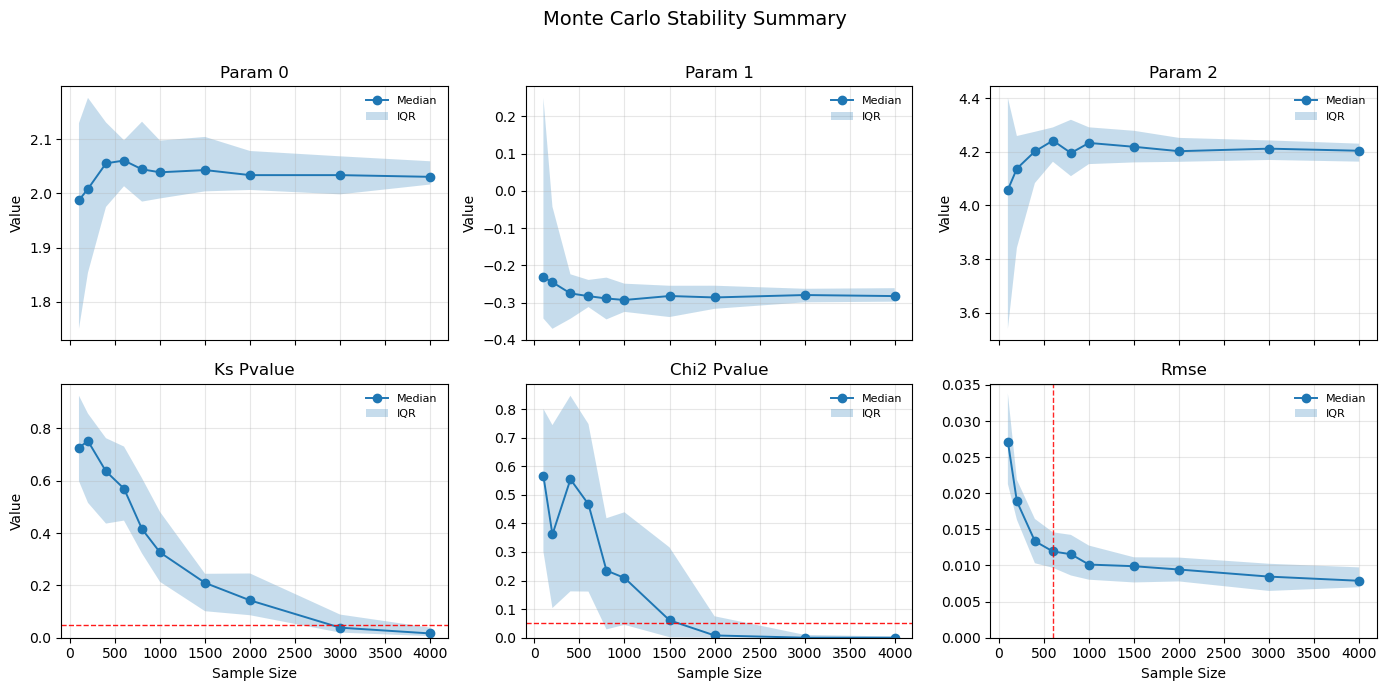

In [11]:
# Run comprehensive Monte Carlo CPS analysis with automatic plotting
print("Running Monte Carlo CPS Analysis on Large Dataset...")
print("This will take a moment as we test multiple subsample sizes...\n")

# Define the sample sizes to test (from small to large)
test_sizes = [100, 200, 400, 600, 800, 1000, 1500, 2000, 3000, 4000]

# IMPORTANT: Include 'rmse' in tests for better stability detection
# RMSE typically shows clearer convergence behavior than p-values
mc_results = large_processor.monte_carlo_fit(
    sizes=test_sizes,              # Sample sizes to test
    n_repeats=50,                  # Number of subsamples per size (more = better statistics)
    tests=['ks', 'chi2', 'rmse'],  # Include RMSE for reliable stability detection
    sampling='random',             # Sampling strategy: 'random', 'bootstrap', or 'disjoint'
    seed=42,                       # For reproducibility
    fig_output_path='cps_analysis.png',  # Automatically generate summary figure
    plot_type='series'             # Use series plot style (alternative: 'boxplots')
)

print("✓ Monte Carlo CPS analysis completed!")
print(f"Results dimensions: {dict(mc_results.dims)}")
print(f"Available variables: {list(mc_results.data_vars.keys())}")
print(f"Figure saved to: {mc_results.attrs['figure_path']}")

# Check for stability points
stability_info = mc_results.attrs['stability_points']
print(f"\nStability Analysis Results:")
print("-" * 40)

# RMSE is usually the most reliable indicator
rmse_stability = stability_info.get('rmse', {})
if rmse_stability.get('size') is not None:
    print(f"✓ RMSE: stabilizes at n = {rmse_stability['size']} (RECOMMENDED)")
    if 'criterion' in rmse_stability:
        print(f"  Convergence criterion: {rmse_stability['criterion']:.4f}")
else:
    print(f"○ RMSE: no clear stability detected")

print("")
for param, info in stability_info.items():
    if param == 'rmse':  # Already printed above
        continue
    if info.get('size') is not None:
        print(f"• {param}: stabilizes at n = {info['size']}")
        if 'criterion' in info:
            print(f"  Convergence criterion: {info['criterion']:.4f}")
    else:
        print(f"• {param}: no clear stability detected")

print(f"\nRecommended subsample size: {rmse_stability['size']}")
print("\n💡 TIP: RMSE typically shows clearer convergence than p-values,")
print("   making it the most reliable metric for stability detection.")

Monte Carlo CPS Summary Figure:


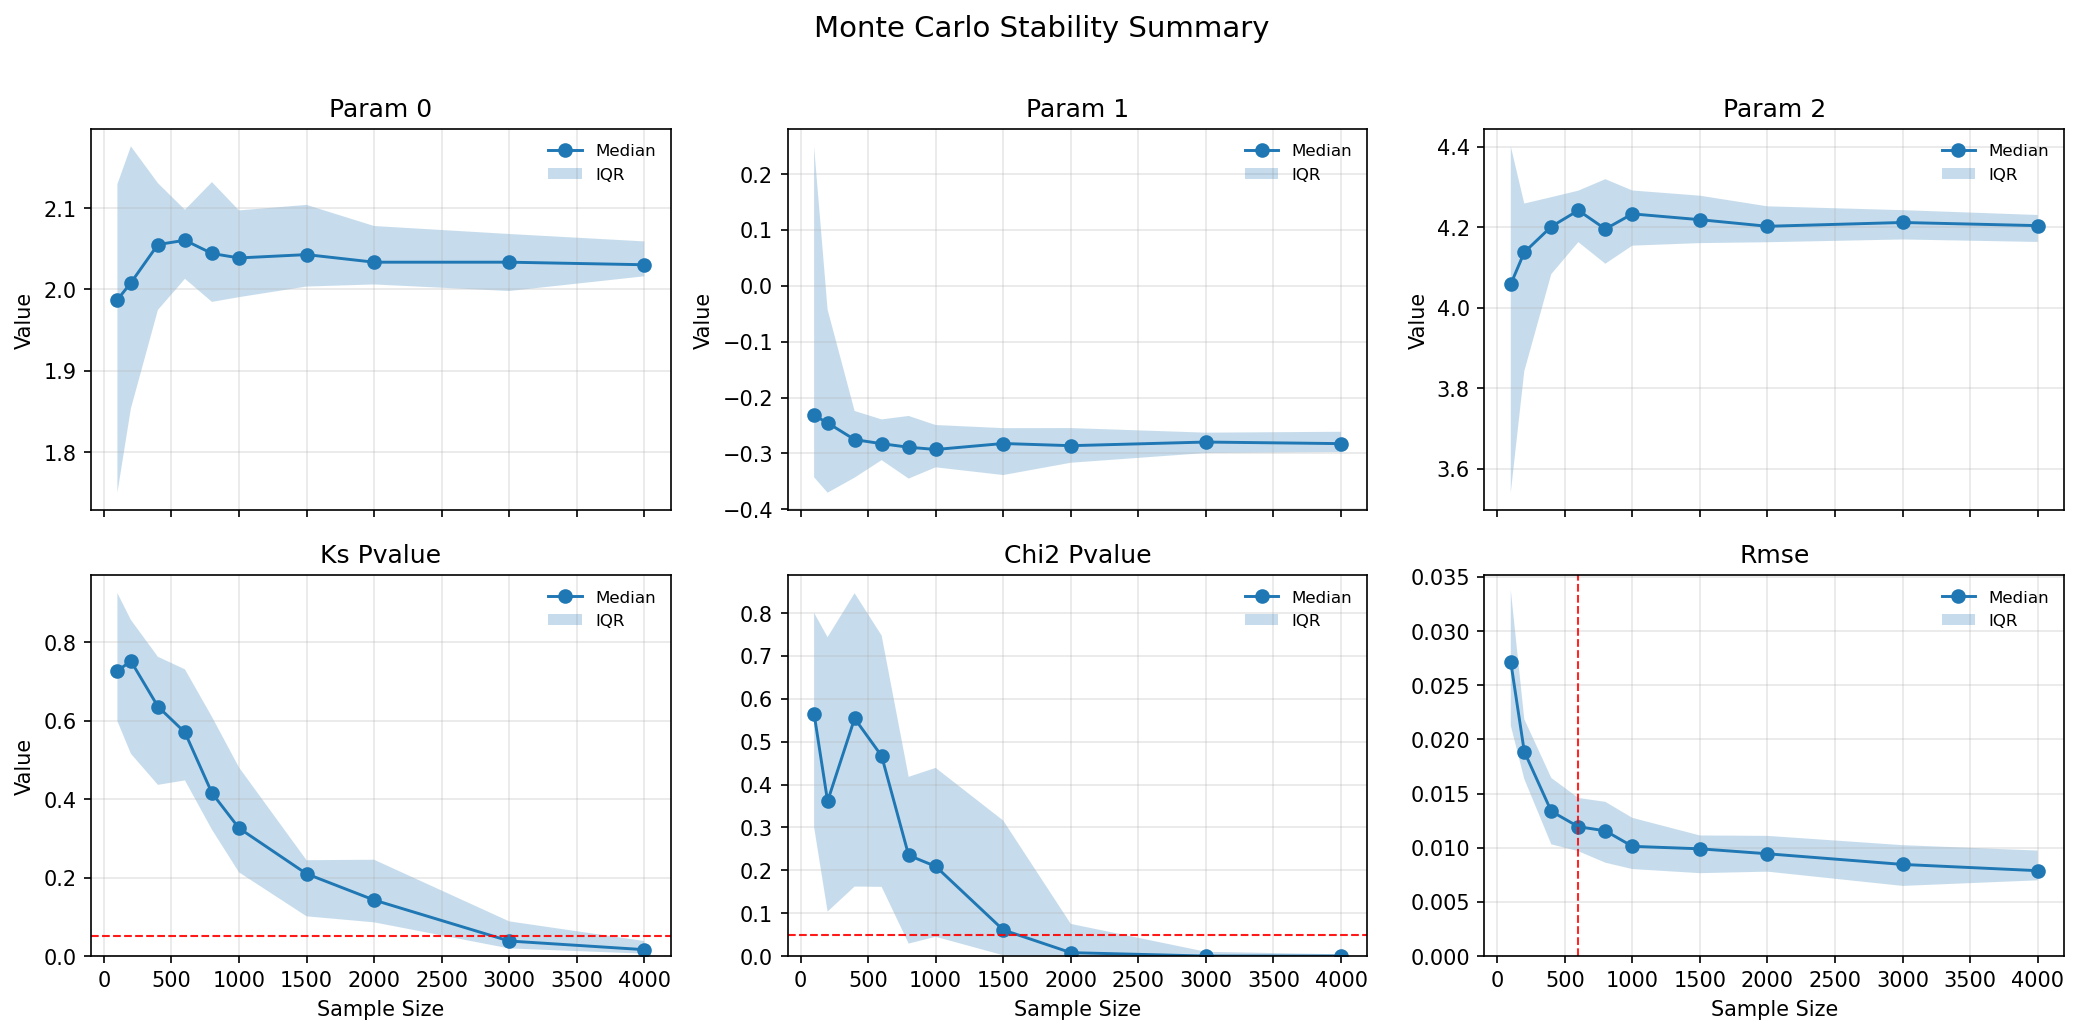


CPS PLOT INTERPRETATION:
📈 TOP ROW - Parameter Stability:
   • Parameters should converge (flatten) as sample size increases
   • Red dashed lines show detected stability points
   • IQR (shaded area) should decrease, showing more precise estimates

📉 BOTTOM ROW - Goodness-of-Fit Evolution:
   • P-values (KS, Chi²) decrease with sample size due to increased power
   • P-values become unreliable for very large samples
   • ⭐ RMSE shows clearest convergence behavior (rightmost plot)
   • RMSE decreases and stabilizes - best metric for stability detection

🎯 KEY INSIGHTS:
   1. Use RMSE stability point for choosing subsample size (most reliable)
   2. P-values are useful but less stable for determining optimal size
   3. Parameters should stabilize before or around RMSE stabilization

💡 RECOMMENDATION:
   Focus on RMSE plot - it typically shows the clearest inflection point
   where the distribution fit quality stabilizes!


In [12]:
# Display the automatically generated CPS figure
from IPython.display import Image, display

# The figure was already created and saved by monte_carlo_fit
figure_path = mc_results.attrs['figure_path']
if figure_path:
    print("Monte Carlo CPS Summary Figure:")
    print("=" * 80)
    display(Image(filename=figure_path))
    
    print("\n" + "="*80)
    print("CPS PLOT INTERPRETATION:")
    print("="*80)
    print("📈 TOP ROW - Parameter Stability:")
    print("   • Parameters should converge (flatten) as sample size increases")
    print("   • Red dashed lines show detected stability points")
    print("   • IQR (shaded area) should decrease, showing more precise estimates")
    print("")
    print("📉 BOTTOM ROW - Goodness-of-Fit Evolution:")  
    print("   • P-values (KS, Chi²) decrease with sample size due to increased power")
    print("   • P-values become unreliable for very large samples")
    print("   • ⭐ RMSE shows clearest convergence behavior (rightmost plot)")
    print("   • RMSE decreases and stabilizes - best metric for stability detection")
    print("")
    print("🎯 KEY INSIGHTS:")
    print("   1. Use RMSE stability point for choosing subsample size (most reliable)")
    print("   2. P-values are useful but less stable for determining optimal size")
    print("   3. Parameters should stabilize before or around RMSE stabilization")
    print("")
    print("💡 RECOMMENDATION:")
    print("   Focus on RMSE plot - it typically shows the clearest inflection point")
    print("   where the distribution fit quality stabilizes!")
else:
    print("Note: To generate the summary figure, provide fig_output_path parameter to monte_carlo_fit()")

### Monte Carlo Sampling Strategies

The `monte_carlo_fit` method offers different sampling strategies, each with specific use cases:

Comparing Monte Carlo Sampling Strategies:
NOTE: Using reduced parameters for demonstration (faster execution)


Testing 'random' sampling...


Monte Carlo sizes: 100%|██████████| 8/8 [00:01<00:00,  6.03it/s]



  RMSE stability: 2000 (primary indicator)
  Shape parameter stability: None
  Figure saved to: mc_sampling_random.png
  ✓ Completed in reasonable time

Testing 'bootstrap' sampling...


Monte Carlo sizes: 100%|██████████| 8/8 [00:01<00:00,  6.25it/s]



  RMSE stability: 2000 (primary indicator)
  Shape parameter stability: None
  Figure saved to: mc_sampling_bootstrap.png
  ✓ Completed in reasonable time

Testing 'disjoint' sampling...


Monte Carlo sizes: 100%|██████████| 8/8 [00:01<00:00,  5.88it/s]



  RMSE stability: 2000 (primary indicator)
  Shape parameter stability: None
  Figure saved to: mc_sampling_disjoint.png
  ✓ Completed in reasonable time

SAMPLING STRATEGY GUIDE:
🎲 RANDOM sampling:
   • Most common approach
   • Each subsample is independently drawn without replacement
   • Good for general stability analysis
   • May have higher variance between subsamples

🔄 BOOTSTRAP sampling:
   • Samples with replacement
   • Useful for uncertainty quantification
   • Can help assess sampling distribution
   • Good for confidence interval estimation
   • Allows subsample size > original data size

📐 DISJOINT sampling (use sampling='disjoint'):
   • Creates non-overlapping partitions
   • Each data point used exactly once per size
   • More representative of data structure
   • Lower variance, more reproducible
   • Good when data has temporal/spatial order

💡 RECOMMENDATION:
   Start with 'random' for general use, try 'disjoint' for ordered data

⚡ PERFORMANCE TIP:
   For product

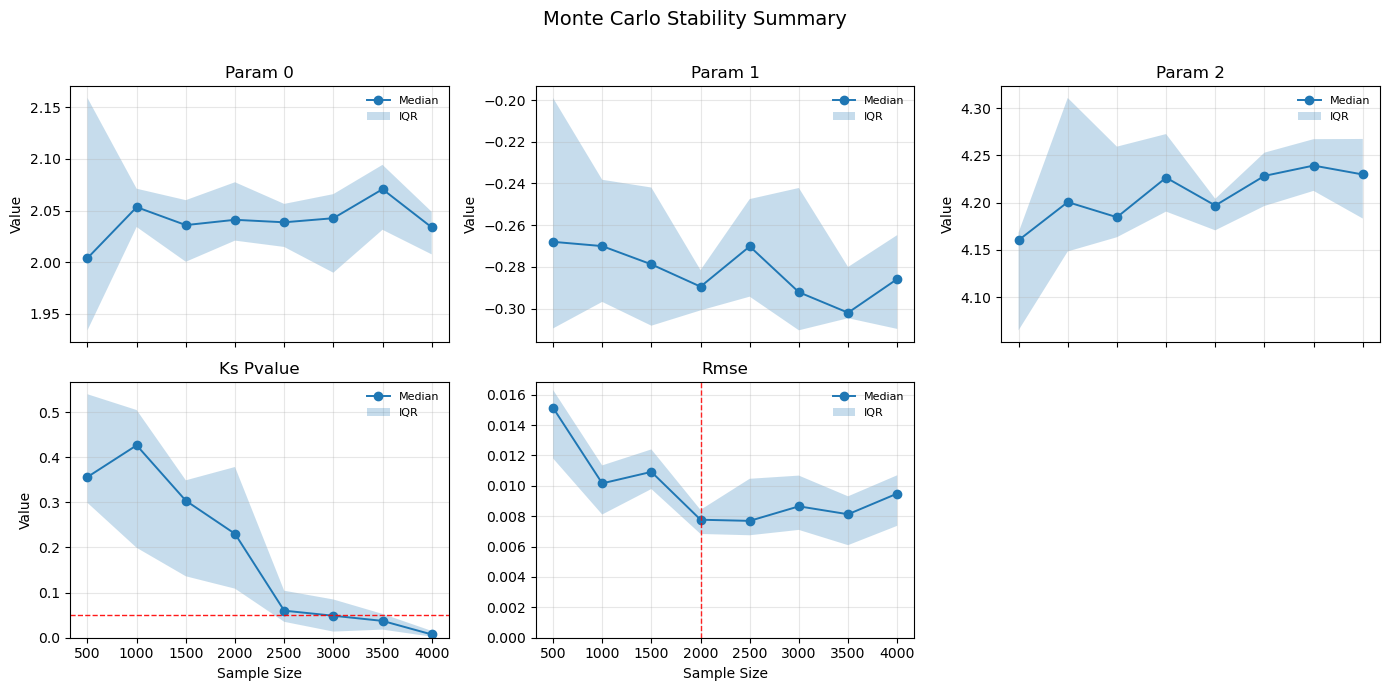

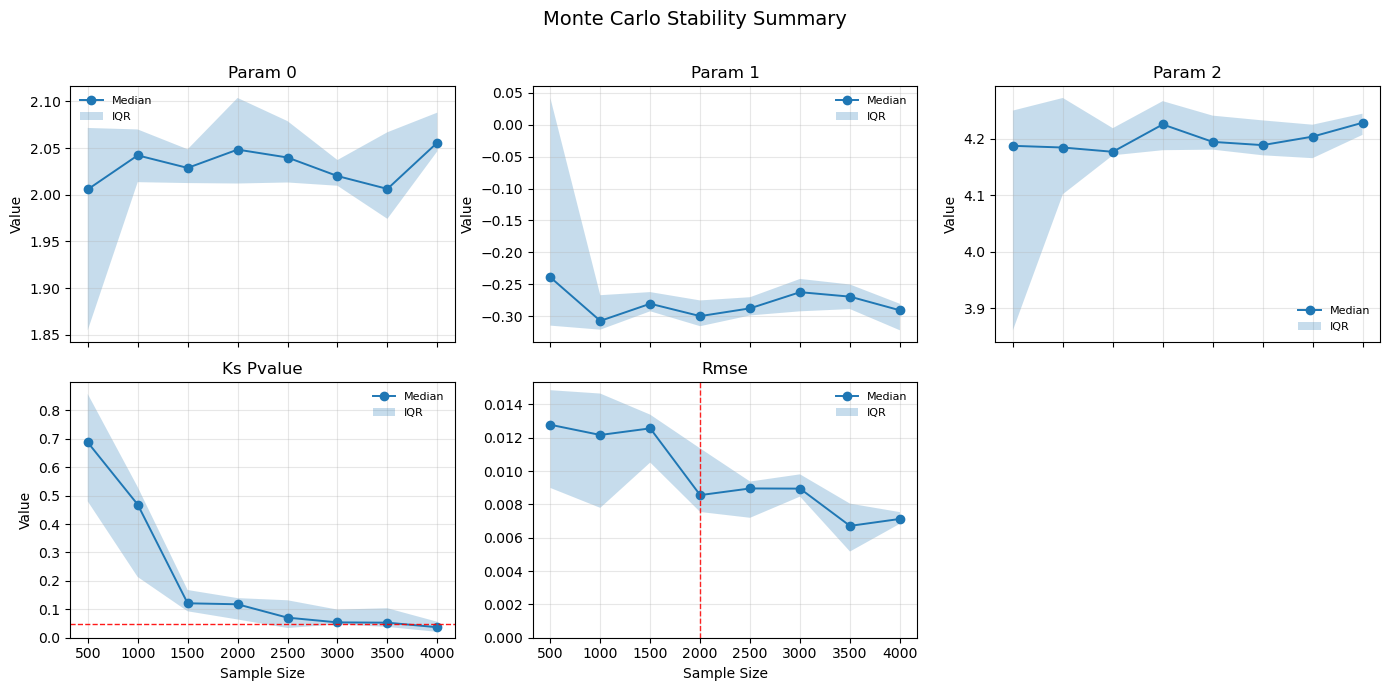

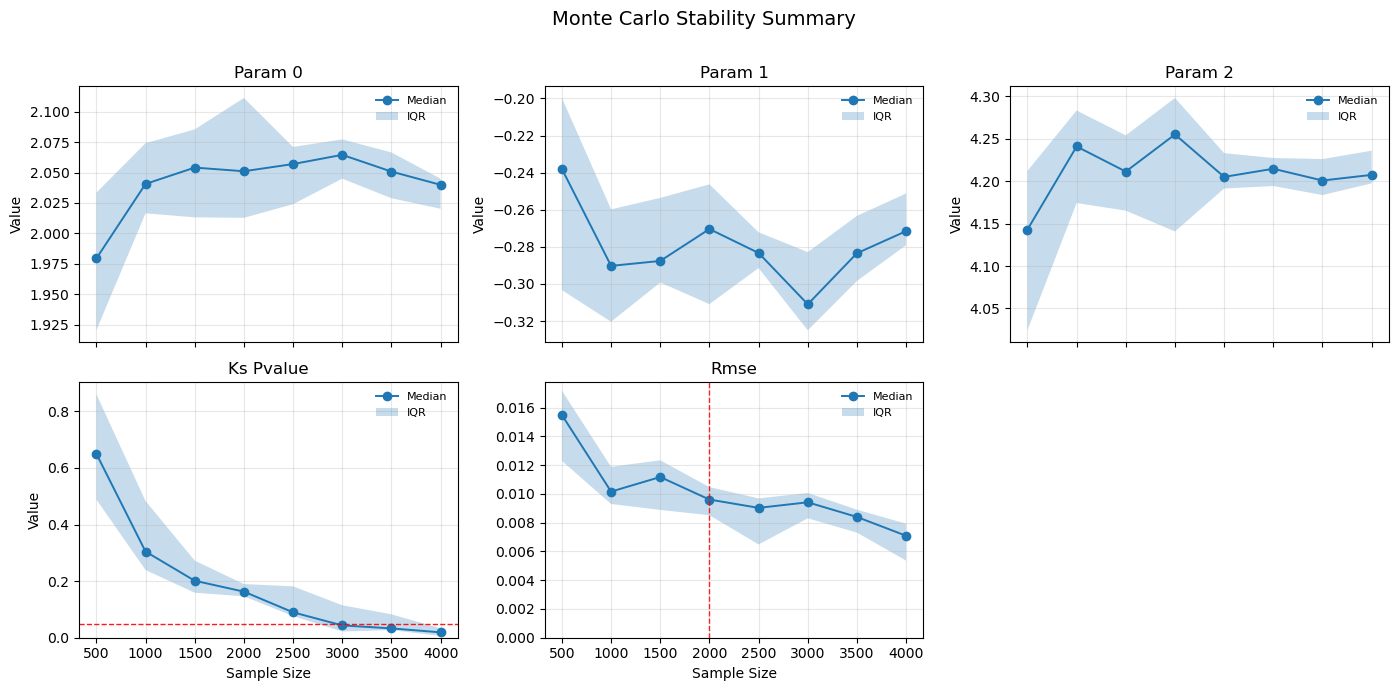

In [13]:
# Compare different sampling strategies
# Using smaller sizes and fewer repeats for demonstration purposes
sampling_strategies = ['random', 'bootstrap', 'disjoint']  # Note: 'disjoint' is also available
strategy_results = {}

print("Comparing Monte Carlo Sampling Strategies:")
print("=" * 60)
print("NOTE: Using reduced parameters for demonstration (faster execution)")
print("")

for i, strategy in enumerate(sampling_strategies):
    print(f"\nTesting '{strategy}' sampling...")
    
    # Run smaller analysis for comparison - optimized for speed
    # Using only 3 sizes and 10 repeats for quick demonstration
    fig_path = f'mc_sampling_{strategy}.png'
    
    mc_strategy = large_processor.monte_carlo_fit(
        sizes=[500, 1000, 1500, 2000, 2500, 3000, 3500, 4000],  # Only 3 sample sizes (was 4)
        n_repeats=10,  # Reduced from 20 for speed
        tests=['ks', 'rmse'],  # Include RMSE for better stability detection
        sampling=strategy,
        seed=42,
        fig_output_path=fig_path,  # Save figure for each strategy
        plot_type='series'
    )
    
    strategy_results[strategy] = mc_strategy
    
    # Check stability - prioritize RMSE
    stability = mc_strategy.attrs['stability_points']
    rmse_stability = stability.get('rmse', {}).get('size', 'Not detected')
    param_0_stability = stability.get('param_0', {}).get('size', 'Not detected')
    
    print(f"  RMSE stability: {rmse_stability} (primary indicator)")
    print(f"  Shape parameter stability: {param_0_stability}")
    print(f"  Figure saved to: {mc_strategy.attrs['figure_path']}")
    print(f"  ✓ Completed in reasonable time")

print("\n" + "="*60)
print("SAMPLING STRATEGY GUIDE:")
print("="*60)
print("🎲 RANDOM sampling:")
print("   • Most common approach")
print("   • Each subsample is independently drawn without replacement")
print("   • Good for general stability analysis")
print("   • May have higher variance between subsamples")
print("")
print("🔄 BOOTSTRAP sampling:")
print("   • Samples with replacement")
print("   • Useful for uncertainty quantification")
print("   • Can help assess sampling distribution")
print("   • Good for confidence interval estimation")
print("   • Allows subsample size > original data size")
print("")
print("📐 DISJOINT sampling (use sampling='disjoint'):")
print("   • Creates non-overlapping partitions")
print("   • Each data point used exactly once per size")
print("   • More representative of data structure")
print("   • Lower variance, more reproducible")
print("   • Good when data has temporal/spatial order")
print("")
print("💡 RECOMMENDATION:")
print("   Start with 'random' for general use, try 'disjoint' for ordered data")
print("")
print("⚡ PERFORMANCE TIP:")
print("   For production analysis, use n_repeats=30-50 and more sample sizes.")
print("   This demo uses reduced parameters for faster execution.")

# Optionally display the comparison figures
print("\n" + "="*60)
print("Generated figures comparing sampling strategies:")
for strategy, results in strategy_results.items():
    print(f"  - {strategy}: {results.attrs['figure_path']}")

### Practical Application: Using Optimal Subsample Size

Now let's apply the CPS method practically by using the optimal subsample size for robust inference:

In [14]:
# Use the recommended subsample size for robust inference
optimal_size = stability_info.get('rmse', {})['size']

print(f"Using optimal subsample size: {optimal_size}")
print("Creating multiple disjoint subsamples for robust inference...\n")

# Create multiple disjoint subsamples of optimal size
n_subsamples = min(5, len(wind_speeds_real) // optimal_size)
subsample_results = []

np.random.seed(42)  # For reproducible subsampling
shuffled_data = wind_speeds_real.copy()
np.random.shuffle(shuffled_data)

for i in range(n_subsamples):
    start_idx = i * optimal_size
    end_idx = (i + 1) * optimal_size
    subsample = shuffled_data[start_idx:end_idx]
    
    # Fit distribution to subsample
    sub_processor = ma.read_data(subsample)
    sub_processor.fit_distribution('weibull_min')
    
    # Get parameters and goodness-of-fit
    params = sub_processor.get_fitted_params()
    ks_test = sub_processor.goodness_of_fit('ks')
    chi2_test = sub_processor.goodness_of_fit('chi2')
    
    subsample_results.append({
        'subsample': i + 1,
        'size': len(subsample),
        'shape_c': params[0],
        'location': params[1], 
        'scale': params[2],
        'ks_pvalue': ks_test['p_value'],
        'chi2_pvalue': chi2_test['p_value']
    })

# Display results
print("Robust Inference Using Optimal Subsample Size:")
print("=" * 80)
print(f"{'Sub':<4} {'Size':<6} {'Shape(c)':<10} {'Location':<10} {'Scale':<10} {'KS p-val':<10} {'Chi2 p-val'}")
print("-" * 80)

for result in subsample_results:
    print(f"{result['subsample']:<4} {result['size']:<6} {result['shape_c']:<10.4f} "
          f"{result['location']:<10.4f} {result['scale']:<10.4f} "
          f"{result['ks_pvalue']:<10.4f} {result['chi2_pvalue']:<10.4f}")

# Calculate empirical statistics
shape_values = [r['shape_c'] for r in subsample_results]
scale_values = [r['scale'] for r in subsample_results] 
ks_pvalues = [r['ks_pvalue'] for r in subsample_results]

print(f"\nEmpirical Distribution Summary:")
print(f"Shape parameter (c):")
print(f"  Mean ± Std: {np.mean(shape_values):.4f} ± {np.std(shape_values):.4f}")
print(f"  Range: [{np.min(shape_values):.4f}, {np.max(shape_values):.4f}]")
print(f"Scale parameter:")
print(f"  Mean ± Std: {np.mean(scale_values):.4f} ± {np.std(scale_values):.4f}")
print(f"  Range: [{np.min(scale_values):.4f}, {np.max(scale_values):.4f}]")
print(f"KS p-values:")
print(f"  Mean ± Std: {np.mean(ks_pvalues):.4f} ± {np.std(ks_pvalues):.4f}")
print(f"  All p-values > 0.05: {all(p > 0.05 for p in ks_pvalues)}")

print(f"\n✅ SUCCESS: By using subsamples of size {optimal_size}:")
print(f"   • Parameters show reasonable variability (not over-precise)")
print(f"   • P-values remain interpretable (not inflated by sample size)")
print(f"   • We get robust empirical confidence intervals")
print(f"   • Practical significance is easier to assess")

Using optimal subsample size: 600
Creating multiple disjoint subsamples for robust inference...

Robust Inference Using Optimal Subsample Size:
Sub  Size   Shape(c)   Location   Scale      KS p-val   Chi2 p-val
--------------------------------------------------------------------------------
1    600    1.8820     0.0486     3.8181     0.6253     0.4811    
2    600    2.2079     -0.4328    4.3590     0.4559     0.0147    
3    600    1.8952     -0.1288    3.9390     0.4138     0.3702    
4    600    2.0543     -0.3206    4.1561     0.7861     0.9895    
5    600    2.0459     -0.3994    4.1184     0.1222     0.2718    

Empirical Distribution Summary:
Shape parameter (c):
  Mean ± Std: 2.0171 ± 0.1198
  Range: [1.8820, 2.2079]
Scale parameter:
  Mean ± Std: 4.0781 ± 0.1863
  Range: [3.8181, 4.3590]
KS p-values:
  Mean ± Std: 0.4807 ± 0.2226
  All p-values > 0.05: True

✅ SUCCESS: By using subsamples of size 600:
   • Parameters show reasonable variability (not over-precise)
   • P-valu

/home/daniloceano/Documents/Programs_and_scripts/MagicA/magica/core/magic_adjuster.py:445: UserWarning: Normalizing expected frequencies. Original sum: 599.673659, Target sum: 600
  warnings.warn(f"Normalizing expected frequencies. Original sum: {expected_freq.sum():.6f}, "
/home/daniloceano/Documents/Programs_and_scripts/MagicA/magica/core/magic_adjuster.py:445: UserWarning: Normalizing expected frequencies. Original sum: 595.728801, Target sum: 600
  warnings.warn(f"Normalizing expected frequencies. Original sum: {expected_freq.sum():.6f}, "
/home/daniloceano/Documents/Programs_and_scripts/MagicA/magica/core/magic_adjuster.py:445: UserWarning: Normalizing expected frequencies. Original sum: 599.023883, Target sum: 600
  warnings.warn(f"Normalizing expected frequencies. Original sum: {expected_freq.sum():.6f}, "
/home/daniloceano/Documents/Programs_and_scripts/MagicA/magica/core/magic_adjuster.py:445: UserWarning: Normalizing expected frequencies. Original sum: 596.587009, Target sum:

## Summary and Best Practices

### Key Points:

1. **Data Loading**: Use `ma.read_data()` to create a `DataProcessor`
2. **Distribution Fitting**: Use `.fit_distribution(distribution_name)` 
3. **Direct Method Access**: All SciPy methods available directly (pdf, cdf, ppf, etc.)
4. **Smart Defaults**: Methods like `pdf()` and `cdf()` use original data when no input provided
5. **Goodness-of-Fit**: Use `.goodness_of_fit()` with 'ks', 'chi2', or 'rmse'
6. **Bin Selection**: Chi-square test supports multiple binning methods ('doane', 'sturges', etc.)
7. **Constraints**: Pass fitting constraints as keyword arguments (e.g., `floc=0`)
8. **Stability Analysis**: Use `monte_carlo_fit()` with automatic figure generation
9. **Large Sample Effects**: For n>5000, use Monte Carlo CPS method to avoid p-value inflation
10. **⭐ RMSE for Stability**: RMSE shows clearest convergence - use it as primary stability indicator

### Recommended Workflows:

#### Standard Analysis (n < 5000):
```python
# 1. Load data
processor = ma.read_data(your_data)

# 2. Fit distribution
processor.fit_distribution('weibull_min')

# 3. Evaluate fit quality with appropriate binning
ks_test = processor.goodness_of_fit('ks')
chi2_test = processor.goodness_of_fit('chi2', bins='doane')  # Choose bins wisely!

# 4. Use fitted distribution
percentile_95 = processor.ppf(0.95)
probability = processor.cdf(threshold_value)

# 5. Run stability analysis with automatic plotting
# IMPORTANT: Include 'rmse' for best stability detection
mc_results = processor.monte_carlo_fit(
    n_repeats=30,
    tests=['ks', 'chi2', 'rmse'],  # RMSE is crucial!
    fig_output_path='stability_analysis.png',
    plot_type='series'
)

# 6. Use RMSE-based stability point (most reliable)
optimal_size = mc_results.attrs['stability_points']['rmse'].get('size')
```

#### Large Dataset Analysis (n > 5000):
```python
# 1. Load data
processor = ma.read_data(large_dataset)

# 2. Run CPS analysis with automatic visualization
# Always include RMSE for clearest stability detection
mc_results = processor.monte_carlo_fit(
    sizes=[100, 200, 500, 1000, 2000],  # Test multiple subsample sizes
    n_repeats=50,
    tests=['ks', 'chi2', 'rmse'],  # RMSE shows best convergence behavior
    sampling='random',
    fig_output_path='cps_analysis.png',  # Auto-generates 2x3 summary plot
    plot_type='series'
)

# 3. Check RMSE stability point (most reliable indicator)
rmse_stability = mc_results.attrs['stability_points']['rmse']
optimal_size = rmse_stability.get('size', mc_results.attrs['recommended_size'])
print(f"Optimal size from RMSE: {optimal_size}")

# 4. Use recommended subsample size for robust inference
# ... split data into subsamples of optimal_size ...
```

### Important Considerations:

- **⭐ RMSE is King**: RMSE typically shows much clearer convergence than p-values
  - P-values can be erratic and unreliable for stability detection
  - RMSE decreases smoothly and shows clear stabilization points
  - **Always include 'rmse' in your tests list** for Monte Carlo analysis
  
- **Chi-square binning**: Different methods can significantly affect results - choose appropriately

- **Large samples**: P-values become unreliable with very large datasets (n>10,000)

- **CPS method**: Helps separate statistical significance from practical significance

- **Sampling strategy**: 
  - 'random': general purpose, independent draws
  - 'bootstrap': with replacement, good for uncertainty estimation
  - 'disjoint': non-overlapping, better for temporal/spatial data

- **Reproducibility**: Always set random seeds for Monte Carlo analyses

- **Automatic plotting**: Use `fig_output_path` parameter to generate publication-ready figures

- **Plot types**: 'series' shows medians with IQR, 'boxplots' shows distribution per size

### Monte Carlo Analysis Features:

The `monte_carlo_fit()` method provides:

1. **Automatic figure generation**: Set `fig_output_path` to save a 2x3 summary plot
2. **Stability detection**: Automatically identifies where parameters/tests stabilize
3. **Multiple tests**: Run KS, Chi-square, and **RMSE** tests simultaneously
4. **Flexible sampling**: Choose between random, bootstrap, or disjoint strategies
5. **Parameter tracking**: Monitor how all distribution parameters evolve with sample size
6. **Recommended size**: Get a suggested optimal subsample size based on stability

### 🎯 Best Practice - Stability Detection:

**Use RMSE as your primary stability indicator:**

1. RMSE shows smooth, monotonic decrease as sample size increases
2. Stabilization point is clearly visible (when curve flattens)
3. More reliable than p-values which can fluctuate
4. Directly measures fit quality improvement

**Visual cue in plots:**
- Look at bottom-right panel (RMSE)
- Find where curve flattens (red dashed line)
- This is your optimal sample size!

For automatic distribution selection, see the AutoFitter tutorial!